### 1. IMPORTACIÓN DE LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Dropout, LSTM, TimeDistributed, RepeatVector
from keras.models import Sequential, load_model
from keras import regularizers
from joblib import dump, load
from datetime import datetime, timedelta
from pytz import timezone
import requests
import arrow

### 2. PULL DE DATOS

In [2]:
# URL base del servidor y endpoint de la API
base_url = 'http://192.168.10.211:55235/api'
endpoint = base_url + '/v2/GetTagData2'

In [3]:
tags = ['PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Condensador.FT_Caudal Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Condensador.TT_Condensado Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Condensador.Trip_SP Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Condensador.PT_VacioCond Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Condensador.LP_Extraccion Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Unidad Lubricacion.TT_Aceite Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Unidad Lubricacion.PT_Filtro Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Unidad Lubricacion.PT_Aceite Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros Operativos.SPD_Gen_01 Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros Operativos.PT_Ingreso Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros Operativos.PT_Turb Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros Operativos.Pot_Act Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros Operativos.TT_Ingreso Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros Operativos.TT_Turb Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.ZT_TurbLeft Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.ZT_TurbRight Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_GenR Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_GenS Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_GenT Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_ExAxial Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_InAxial Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_RadialGenLA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_RadialGenLL Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_RadialLPLA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_RadialLPLL Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_RadialLA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.TT_RadialLL Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_TurbLLA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_TurbLLB Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_TurbLAA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_TurbLAB Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_ReductorLeftLA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_ReductorRightLA Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_ReductorLeftLL Value Y',
        'PEAAAUCOI211.Extraccion_data.GenElect.Turbina.Parametros de Estado.VT_ReductorRightLL Value Y'
        ]

columnas = ['Condensador/FT_Caudal', 
 'Condensador/TT_Condensado', 
 'Condensador/Trip_SP', 
 'Condensador/PT_VacioCond', 
 'Condensador/LP_Extraccion', 
 'U. Lub/TT_Aceite', 
 'U. Lub/PT_Filtro', 
 'U. Lub/PT_Aceite', 
 'Param. Op./SPD_Gen_01', 
 'Param. Op./PT_Ingreso', 
 'Param. Op./PT_Turb', 
 'Param. Op./Pot_Act', 
 'Param. Op./TT_Ingreso', 
 'Param. Op./TT_Turb', 
 'Param. Estado/ZT_TurbLeft', 
 'Param. Estado/ZT_TurbRight', 
 'Param. Estado/TT_R', 
 'Param. Estado/TT_S', 
 'Param. Estado/TT_T', 
 'Param. Estado/TT_ExAxial', 
 'Param. Estado/TT_InAxial', 
 'Param. Estado/TT_RadialGenLA', 
 'Param. Estado/TT_RadialGenLL', 
 'Param. Estado/TT_RadialLPLA', 
 'Param. Estado/TT_RadialLPLL', 
 'Param. Estado/TT_RadialLA', 
 'Param. Estado/TT_RadialLL', 
 'Param. Estado/VT_ReductorLeftLA', 
 'Param. Estado/VT_ReductorRightLA', 
 'Param. Estado/VT_ReductorLeftLL', 
 'Param. Estado/VT_ReductorRightLL', 
 'Param. Estado/VT_TurbLLA', 
 'Param. Estado/VT_TurbLLB',
 'Param. Estado/VT_TurbLAA',
 'Param. Estado/VT_TurbLAB'] 

In [4]:
# Cuerpo de la solicitud
myobj = {
    "userToken": "",
    "tags": tags,
    "startTime": "now-1d",
    "endTime": "now",
    "aggregateName": "TimeAverage",
    "aggregateInterval": "00:0:30",
}

attempts = 0

while attempts <5:
    try:
        # Realizar la solicitud POST
        response = requests.post(url=endpoint, json=myobj)
        # Verificar que la solicitud fue exitosa
        if response.status_code == 200:
            # Convertir la respuesta JSON
            data = response.json()
            
            # Crear un diccionario para almacenar los datos de cada tag
            tag_dfs = {}

            # Iterar sobre cada tag en la respuesta
            for tag in tags:
                if tag in data['data']:
                    tag_data = data['data'][tag]
                    
                    # Extraer timestamps y valores para el tag actual
                    timestamps = [item['t'] for item in tag_data]
                    values = [item['v'] for item in tag_data]
                    
                    # Crear un DataFrame temporal para el tag actual
                    tag_df = pd.DataFrame({tag: values}, index=pd.to_datetime(timestamps))
                    
                    # Agregar el DataFrame temporal al diccionario
                    tag_dfs[tag] = tag_df

            # Combinar todos los DataFrames en uno solo, usando el índice de tiempo
            combined_df = pd.concat(tag_dfs.values(), axis=1)
            print(f'Intento exitoso #{attempts+1}')
            break #Salir del bucle si fue exitoso
        else:
            print("Error en la solicitud:", response.status_code)
            print(response.text)
    except:
        attempts +=1
        print(f'Error en la consulta, attempt # {attempts}')

data = combined_df
data.columns = columnas
data.index = pd.to_datetime(data.index,format='ISO8601').tz_convert('America/Lima')
print(data.shape)
data.describe()

Intento exitoso #1
(2880, 35)


,Condensador/FT_Caudal,Condensador/TT_Condensado,Condensador/Trip_SP,Condensador/PT_VacioCond,Condensador/LP_Extraccion,U. Lub/TT_Aceite,U. Lub/PT_Filtro,U. Lub/PT_Aceite,Param. Op./SPD_Gen_01,Param. Op./PT_Ingreso,...,Param. Estado/TT_RadialLA,Param. Estado/TT_RadialLL,Param. Estado/VT_ReductorLeftLA,Param. Estado/VT_ReductorRightLA,Param. Estado/VT_ReductorLeftLL,Param. Estado/VT_ReductorRightLL,Param. Estado/VT_TurbLLA,Param. Estado/VT_TurbLLB,Param. Estado/VT_TurbLAA,Param. Estado/VT_TurbLAB
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,...,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,20.107824,41.371308,0.037316,-0.911287,24.413963,46.605404,0.185214,8.906170,6824.206732,58.226716,...,83.841432,58.127875,11.420050,12.272156,34.785238,30.719771,27.288638,15.102507,28.000319,19.190001
std,2.048649,0.850207,0.036412,0.005148,20.628749,0.658404,0.001871,0.007994,59.988752,3.287549,...,0.336735,0.610688,0.436923,0.385268,0.676460,0.717475,0.499720,0.520892,0.150014,0.676513
min,17.385271,39.689429,-0.172464,-0.921074,0.000000,45.400002,0.179354,8.881800,6048.305566,45.695601,...,83.109887,56.900002,10.439834,10.763515,32.466305,28.857245,26.369247,14.469412,27.141610,18.196140
25%,18.936355,40.861094,0.023477,-0.914738,0.064625,46.200001,0.183905,8.900832,6828.961665,56.846156,...,83.599998,57.700001,11.106588,12.043712,34.272584,30.169642,27.057859,14.870954,27.906393,18.887070
50%,19.601517,41.156924,0.042549,-0.913185,31.751885,46.404168,0.185204,8.906425,6830.977226,59.267154,...,83.800003,57.991722,11.340355,12.243378,34.904539,30.753025,27.241558,15.078596,28.011179,19.205399
75%,20.481731,41.735597,0.056317,-0.908391,39.927569,47.099998,0.186514,8.911712,6833.073067,60.523528,...,84.099998,58.523389,11.688008,12.453836,35.228504,31.226207,27.455746,15.235555,28.103436,19.427027
max,36.229983,46.347287,0.113449,-0.882306,69.369295,47.900002,0.192572,8.939815,6847.026654,64.945654,...,84.500000,59.500000,13.395392,14.099214,41.110681,33.612027,40.429660,24.377182,28.429836,31.319244


In [5]:
# days=0.25 #Dias para el deployment

# items = pd.read_csv('signals/items_turbina_filtered.csv')

# attempts = 0
# while attempts < 5:
#     try:
#         end = datetime.now(timezone('America/Lima'))
#         start = end-timedelta(days=days) 
#         #Extracción de datos del Workbench
#         data = spy.pull(items,start=start, end=end,grid='1 min',tz_convert='America/Lima', quiet=False)
#         print(f'Intento exitoso #{attempts+1}')
#         break
#     except:
#         attempts += 1
#         print(f'Error en Seeq Workbench, attempt #{attempts}')    
# print(data.shape)
# data.describe()

In [6]:
# def moving_average(data_set, periods=3):
#     weights = np.ones(periods) / periods
#     return np.convolve(data_set, weights, mode='valid')
def moving_average_filter(data, columns, window_size):
    filtered_data = data.copy()
    for column in columns:
        filtered_data[column] = data[column].rolling(window=window_size,min_periods=1).mean()
    return filtered_data

In [7]:
column_to_filter2 = ["Condensador/FT_Caudal",
                    "Condensador/TT_Condensado",
                    "Condensador/Trip_SP",
                    "Condensador/PT_VacioCond",
                    "Condensador/LP_Extraccion",
                    "U. Lub/TT_Aceite",
                    "U. Lub/PT_Filtro",
                    "U. Lub/PT_Aceite",
                    "Param. Op./PT_Ingreso",
                    "Param. Op./PT_Turb",
                    "Param. Op./Pot_Act",
                    "Param. Op./TT_Ingreso",
                    "Param. Op./TT_Turb",
                    "Param. Estado/ZT_TurbLeft",
                    "Param. Estado/ZT_TurbRight",
                    "Param. Estado/TT_ExAxial",
                    "Param. Estado/TT_InAxial",
                    "Param. Estado/TT_RadialGenLA",
                    "Param. Estado/TT_RadialGenLL",
                    "Param. Estado/TT_RadialLPLA",
                    "Param. Estado/TT_RadialLPLL",
                    "Param. Estado/TT_RadialLA",
                    "Param. Estado/TT_RadialLL"
                    ]

column_to_filter1 = ["Param. Estado/VT_ReductorLeftLA",
                     "Param. Estado/VT_ReductorRightLA",
                     "Param. Estado/VT_ReductorLeftLL",
                     "Param. Estado/VT_ReductorRightLL",
                     "Param. Estado/VT_TurbLLA",
                     "Param. Estado/VT_TurbLLB",
                     "Param. Estado/VT_TurbLAA",
                     "Param. Estado/VT_TurbLAB"]

data['Param. Op./SPD_Gen_01'] = data['Param. Op./SPD_Gen_01'][data['Param. Op./SPD_Gen_01'] > 0]
data['Param. Estado/ZT_TurbLeft'] = data['Param. Estado/ZT_TurbLeft'][data['Param. Estado/ZT_TurbLeft'] > -0.6]
data['Param. Estado/ZT_TurbRight'] = data['Param. Estado/ZT_TurbRight'][data['Param. Estado/ZT_TurbRight'] > -0.6]
data['Param. Estado/TT_MEAN_GEN'] = (data['Param. Estado/TT_R'] + data['Param. Estado/TT_S'] + data['Param. Estado/TT_T'])/3
data.drop(columns=['Param. Estado/TT_R','Param. Estado/TT_S','Param. Estado/TT_T'],inplace=True)
data['Param. Estado/TT_RadialGenLA'] = data['Param. Estado/TT_RadialGenLA'][data['Param. Estado/TT_RadialGenLA']<200]
data['Param. Estado/TT_RadialGenLL'] = data['Param. Estado/TT_RadialGenLL'][data['Param. Estado/TT_RadialGenLL']<200]
data['Param. Estado/TT_RadialLPLA'] = data['Param. Estado/TT_RadialLPLA'][data['Param. Estado/TT_RadialLPLA']<200] 
data['Param. Estado/TT_RadialLPLL'] = data['Param. Estado/TT_RadialLPLL'][data['Param. Estado/TT_RadialLPLL']<200]
data['Param. Estado/TT_RadialLA'] = data['Param. Estado/TT_RadialLA'][data['Param. Estado/TT_RadialLA']<500] 
data['Param. Estado/TT_RadialLL'] = data['Param. Estado/TT_RadialLL'][data['Param. Estado/TT_RadialLL']<500]
data['Param. Estado/VT_ReductorLeftLA'] = data['Param. Estado/TT_RadialGenLA'][data['Param. Estado/TT_RadialGenLA']<100]
data['Param. Estado/VT_ReductorRightLA'] = data['Param. Estado/VT_ReductorRightLA'][data['Param. Estado/VT_ReductorRightLA']<100]
data['Param. Estado/VT_ReductorLeftLL'] = data['Param. Estado/VT_ReductorLeftLL'][data['Param. Estado/VT_ReductorLeftLL']<100]
data['Param. Estado/VT_ReductorRightLL'] = data['Param. Estado/VT_ReductorRightLL'][data['Param. Estado/VT_ReductorRightLL']<100]
data['Param. Estado/VT_TurbLLA'] = data['Param. Estado/VT_TurbLLA'][data['Param. Estado/VT_TurbLLA']<100]
data['Param. Estado/VT_TurbLLB'] = data['Param. Estado/VT_TurbLLB'][data['Param. Estado/VT_TurbLLB']<100] 
data['Param. Estado/VT_TurbLAA'] = data['Param. Estado/VT_TurbLAA'][data['Param. Estado/VT_TurbLAA']<100]
data['Param. Estado/VT_TurbLAB'] = data['Param. Estado/VT_TurbLAB'][data['Param. Estado/VT_TurbLAB']<100] 

df_filt = moving_average_filter(data,column_to_filter1,'10s')
df_filt = moving_average_filter(df_filt,column_to_filter2,'20s')
# for item in df.columns:
#     plt.figure(figsize=(20, 6))
#     # Graficar la data original
#     plt.plot(data[item], label=f'{item} - Original', linestyle='-', color='blue')
#     # Graficar la data filtrada
#     plt.plot(df_filt[item], label=f'{item} - Filtrada', linestyle='--', color='orange')
    
#     plt.title(item)
#     plt.legend()
#     plt.show()

In [8]:
df_filt.tail()

,Condensador/FT_Caudal,Condensador/TT_Condensado,Condensador/Trip_SP,Condensador/PT_VacioCond,Condensador/LP_Extraccion,U. Lub/TT_Aceite,U. Lub/PT_Filtro,U. Lub/PT_Aceite,Param. Op./SPD_Gen_01,Param. Op./PT_Ingreso,...,Param. Estado/TT_RadialLL,Param. Estado/VT_ReductorLeftLA,Param. Estado/VT_ReductorRightLA,Param. Estado/VT_ReductorLeftLL,Param. Estado/VT_ReductorRightLL,Param. Estado/VT_TurbLLA,Param. Estado/VT_TurbLLB,Param. Estado/VT_TurbLAA,Param. Estado/VT_TurbLAB,Param. Estado/TT_MEAN_GEN
2025-01-15 08:05:30.466605100-05:00,19.098199,40.038709,0.034912,-0.919579,0.005667,45.599998,0.186098,8.909583,6817.421119,57.262784,...,57.200001,68.0,12.136858,35.469266,30.887582,27.613126,15.600037,27.771311,19.278600,67.966665
2025-01-15 08:06:00.466605100-05:00,19.354330,40.051118,0.032886,-0.919599,0.000000,45.599998,0.185625,8.907793,6818.966667,57.212243,...,57.200001,68.0,12.111815,35.396517,30.847939,27.387801,15.363237,27.704070,19.174908,67.966665
2025-01-15 08:06:30.466605100-05:00,18.761306,40.045331,0.037068,-0.919657,0.000000,45.599998,0.184252,8.908200,6818.917780,57.073457,...,57.200001,68.0,12.101824,35.287289,30.948741,27.797781,15.663291,27.745432,19.133098,67.966665
2025-01-15 08:07:00.466605100-05:00,18.775220,40.000065,0.029336,-0.920523,0.005000,45.599998,0.189684,8.925329,6821.162214,56.952649,...,57.200001,68.0,12.120656,35.201291,30.853719,27.852257,15.668065,27.681412,19.106058,67.966665
2025-01-15 08:07:30.466605100-05:00,19.303387,39.988426,0.028205,-0.920718,0.000000,45.599998,0.190972,8.939815,6821.000000,56.944443,...,57.200001,68.0,12.062257,35.124741,30.860609,27.808041,15.643549,27.661554,19.134813,67.966665


In [9]:
# Se crean las condiciones para 'Turbina - Apagado', 'Turbina - Modo Extracción', 'Turbina - Modo Condensación' y 'Estado turbina'
# ForecastConstant simulada (promedio movil de 5 dias)
df_filt['Turbina - Apagado'] = df_filt['Param. Op./Pot_Act'].rolling('5D',min_periods=1).mean()
# Se crea la condición para Pot_Act <1 y 'Turbina - Apagado' is invalid
df_filt['Turbina - Apagado'] = (df_filt['Param. Op./Pot_Act']<1 | (df_filt['Turbina - Apagado'].isna()))
# Merge de intervalos dentro de 10 minutos
df_filt['Turbina - Apagado'] = df_filt['Turbina - Apagado'].astype(int)  # Convertir a entero
df_filt['Turbina - Apagado'] = (
    df_filt['Turbina - Apagado']
    .groupby((df_filt['Turbina - Apagado'].diff().fillna(0) != 0).cumsum())
    .transform(lambda group: group.index[-1] - group.index[0] <= pd.Timedelta(minutes=10))
)

df_filt['Turbina - Apagado'] = df_filt['Turbina - Apagado'].map({True:'Apagado',False:'Encendido'})

df_filt['Turbina - Modo Extraccion'] = (df_filt['Param. Op./Pot_Act']>1) & (df_filt['Param. Op./SPD_Gen_01']>500) & (df_filt['Condensador/LP_Extraccion']<95) & (df_filt['Turbina - Apagado']=='Encendido')
df_filt['Turbina - Modo Condensacion'] = (df_filt['Turbina - Apagado']=='Encendido') & (df_filt['Turbina - Modo Extraccion']==False)

# Definir las condiciones para 'Estado Caldero'
condiciones = [
    (df_filt['Turbina - Apagado'] == 'Apagado'),
    (df_filt['Turbina - Modo Extraccion']),
    (df_filt['Turbina - Modo Condensacion'])
]

# Definir los valores que se asignarán a 'Estado Caldero'
valores = ['Apagado', 'Extraccion', 'Condensacion']

# Crear la columna 'Estado Caldero' usando np.select
df_filt['Estado turbina'] = np.select(condiciones, valores, default='Encendido')

# Eliminar las columnas temporales
df_filt = df_filt.drop(columns=['Turbina - Apagado', 'Turbina - Modo Extraccion', 'Turbina - Modo Condensacion'])

In [10]:
data = df_filt

In [11]:
data.iloc[:, -60:] = data.iloc[:, -60:].ffill(axis=0)
data.tail(10)

,Condensador/FT_Caudal,Condensador/TT_Condensado,Condensador/Trip_SP,Condensador/PT_VacioCond,Condensador/LP_Extraccion,U. Lub/TT_Aceite,U. Lub/PT_Filtro,U. Lub/PT_Aceite,Param. Op./SPD_Gen_01,Param. Op./PT_Ingreso,...,Param. Estado/VT_ReductorLeftLA,Param. Estado/VT_ReductorRightLA,Param. Estado/VT_ReductorLeftLL,Param. Estado/VT_ReductorRightLL,Param. Estado/VT_TurbLLA,Param. Estado/VT_TurbLLB,Param. Estado/VT_TurbLAA,Param. Estado/VT_TurbLAB,Param. Estado/TT_MEAN_GEN,Estado turbina
2025-01-15 08:03:00.466605100-05:00,18.478029,40.043531,0.027043,-0.919599,0.000000,45.599998,0.186232,8.918961,6822.858875,58.255531,...,68.003333,12.351046,35.598083,31.127458,27.766605,15.452946,27.666383,19.220243,67.966665,Extraccion
2025-01-15 08:03:30.466605100-05:00,18.825515,40.039480,0.034194,-0.919734,0.000000,45.599998,0.183080,8.896456,6821.272232,58.088298,...,68.000000,12.218523,35.519463,31.202891,27.213083,15.429204,27.704741,19.089294,67.966665,Extraccion
2025-01-15 08:04:00.466605100-05:00,18.170986,40.033693,0.037070,-0.919589,0.001333,45.599998,0.185648,8.910828,6817.571119,57.726492,...,68.000000,12.151428,35.591424,31.068188,27.535219,15.431321,27.671138,19.196684,67.966665,Extraccion
2025-01-15 08:04:30.466605100-05:00,18.681383,40.043402,0.032350,-0.919560,0.123188,45.599998,0.184076,8.910216,6817.279994,57.449692,...,68.000000,12.264187,35.406158,31.017957,27.274835,15.528279,27.700515,19.222162,67.966665,Extraccion
2025-01-15 08:05:00.466605100-05:00,18.874244,40.083783,0.036689,-0.919503,0.031978,45.599998,0.187199,8.913231,6818.879994,57.304090,...,68.000000,12.117445,35.494010,30.961265,27.581584,15.539856,27.686546,19.144797,67.966665,Extraccion
2025-01-15 08:05:30.466605100-05:00,19.098199,40.038709,0.034912,-0.919579,0.005667,45.599998,0.186098,8.909583,6817.421119,57.262784,...,68.000000,12.136858,35.469266,30.887582,27.613126,15.600037,27.771311,19.278600,67.966665,Extraccion
2025-01-15 08:06:00.466605100-05:00,19.354330,40.051118,0.032886,-0.919599,0.000000,45.599998,0.185625,8.907793,6818.966667,57.212243,...,68.000000,12.111815,35.396517,30.847939,27.387801,15.363237,27.704070,19.174908,67.966665,Extraccion
2025-01-15 08:06:30.466605100-05:00,18.761306,40.045331,0.037068,-0.919657,0.000000,45.599998,0.184252,8.908200,6818.917780,57.073457,...,68.000000,12.101824,35.287289,30.948741,27.797781,15.663291,27.745432,19.133098,67.966665,Extraccion
2025-01-15 08:07:00.466605100-05:00,18.775220,40.000065,0.029336,-0.920523,0.005000,45.599998,0.189684,8.925329,6821.162214,56.952649,...,68.000000,12.120656,35.201291,30.853719,27.852257,15.668065,27.681412,19.106058,67.966665,Extraccion
2025-01-15 08:07:30.466605100-05:00,19.303387,39.988426,0.028205,-0.920718,0.000000,45.599998,0.190972,8.939815,6821.000000,56.944443,...,68.000000,12.062257,35.124741,30.860609,27.808041,15.643549,27.661554,19.134813,67.966665,Extraccion


### 3. PROCESAMIENTOS DE DATOS

In [12]:
df = data
df.columns = ['Condensador/FT_Caudal', 
 'Condensador/TT_Condensado', 
 'Condensador/Trip_SP', 
 'Condensador/PT_VacioCond', 
 'Condensador/LP_Extraccion', 
 'U. Lub/TT_Aceite', 
 'U. Lub/PT_Filtro', 
 'U. Lub/PT_Aceite', 
 'Param. Op./SPD_Gen_01', 
 'Param. Op./PT_Ingreso', 
 'Param. Op./PT_Turb', 
 'Param. Op./Pot_Act', 
 'Param. Op./TT_Ingreso', 
 'Param. Op./TT_Turb', 
 'Param. Estado/ZT_TurbLeft', 
 'Param. Estado/ZT_TurbRight', 
 'Param. Estado/TT_ExAxial', 
 'Param. Estado/TT_InAxial', 
 'Param. Estado/TT_RadialGenLA', 
 'Param. Estado/TT_RadialGenLL', 
 'Param. Estado/TT_RadialLPLA', 
 'Param. Estado/TT_RadialLPLL', 
 'Param. Estado/TT_RadialLA', 
 'Param. Estado/TT_RadialLL', 
 'Param. Estado/VT_ReductorLeftLA', 
 'Param. Estado/VT_ReductorRightLA', 
 'Param. Estado/VT_ReductorLeftLL', 
 'Param. Estado/VT_ReductorRightLL', 
 'Param. Estado/VT_TurbLLA', 
 'Param. Estado/VT_TurbLLB',
 'Param. Estado/VT_TurbLAA',
 'Param. Estado/VT_TurbLAB',
 'Param. Estado/TT_MEAN_GEN', 
 'Estado turbina']


df['Estado turbina'][-10:] = np.where(df['Param. Op./Pot_Act'][-10:] > 1, 'Extracion', df['Estado turbina'][-10:])
df.tail(10)

C:\Users\Administrador\AppData\Local\Temp\ipykernel_3460\1249400894.py:38: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Estado turbina'][-10:] = np.where(df['Param. Op./Pot_Act'][-10:] > 1, 'Extracion', df['Estado turbina'][-10:])
C:\Us

,Condensador/FT_Caudal,Condensador/TT_Condensado,Condensador/Trip_SP,Condensador/PT_VacioCond,Condensador/LP_Extraccion,U. Lub/TT_Aceite,U. Lub/PT_Filtro,U. Lub/PT_Aceite,Param. Op./SPD_Gen_01,Param. Op./PT_Ingreso,...,Param. Estado/VT_ReductorLeftLA,Param. Estado/VT_ReductorRightLA,Param. Estado/VT_ReductorLeftLL,Param. Estado/VT_ReductorRightLL,Param. Estado/VT_TurbLLA,Param. Estado/VT_TurbLLB,Param. Estado/VT_TurbLAA,Param. Estado/VT_TurbLAB,Param. Estado/TT_MEAN_GEN,Estado turbina
2025-01-15 08:03:00.466605100-05:00,18.478029,40.043531,0.027043,-0.919599,0.000000,45.599998,0.186232,8.918961,6822.858875,58.255531,...,68.003333,12.351046,35.598083,31.127458,27.766605,15.452946,27.666383,19.220243,67.966665,Extracion
2025-01-15 08:03:30.466605100-05:00,18.825515,40.039480,0.034194,-0.919734,0.000000,45.599998,0.183080,8.896456,6821.272232,58.088298,...,68.000000,12.218523,35.519463,31.202891,27.213083,15.429204,27.704741,19.089294,67.966665,Extracion
2025-01-15 08:04:00.466605100-05:00,18.170986,40.033693,0.037070,-0.919589,0.001333,45.599998,0.185648,8.910828,6817.571119,57.726492,...,68.000000,12.151428,35.591424,31.068188,27.535219,15.431321,27.671138,19.196684,67.966665,Extracion
2025-01-15 08:04:30.466605100-05:00,18.681383,40.043402,0.032350,-0.919560,0.123188,45.599998,0.184076,8.910216,6817.279994,57.449692,...,68.000000,12.264187,35.406158,31.017957,27.274835,15.528279,27.700515,19.222162,67.966665,Extracion
2025-01-15 08:05:00.466605100-05:00,18.874244,40.083783,0.036689,-0.919503,0.031978,45.599998,0.187199,8.913231,6818.879994,57.304090,...,68.000000,12.117445,35.494010,30.961265,27.581584,15.539856,27.686546,19.144797,67.966665,Extracion
2025-01-15 08:05:30.466605100-05:00,19.098199,40.038709,0.034912,-0.919579,0.005667,45.599998,0.186098,8.909583,6817.421119,57.262784,...,68.000000,12.136858,35.469266,30.887582,27.613126,15.600037,27.771311,19.278600,67.966665,Extracion
2025-01-15 08:06:00.466605100-05:00,19.354330,40.051118,0.032886,-0.919599,0.000000,45.599998,0.185625,8.907793,6818.966667,57.212243,...,68.000000,12.111815,35.396517,30.847939,27.387801,15.363237,27.704070,19.174908,67.966665,Extracion
2025-01-15 08:06:30.466605100-05:00,18.761306,40.045331,0.037068,-0.919657,0.000000,45.599998,0.184252,8.908200,6818.917780,57.073457,...,68.000000,12.101824,35.287289,30.948741,27.797781,15.663291,27.745432,19.133098,67.966665,Extracion
2025-01-15 08:07:00.466605100-05:00,18.775220,40.000065,0.029336,-0.920523,0.005000,45.599998,0.189684,8.925329,6821.162214,56.952649,...,68.000000,12.120656,35.201291,30.853719,27.852257,15.668065,27.681412,19.106058,67.966665,Extracion
2025-01-15 08:07:30.466605100-05:00,19.303387,39.988426,0.028205,-0.920718,0.000000,45.599998,0.190972,8.939815,6821.000000,56.944443,...,68.000000,12.062257,35.124741,30.860609,27.808041,15.643549,27.661554,19.134813,67.966665,Extracion


In [13]:
df = df[df['Estado turbina']!='Apagado']
df = df.drop(columns=['Estado turbina'])
 
# Reglas de Limpieza
df['Condensador/FT_Caudal'] = df['Condensador/FT_Caudal'].clip(0, 200)
df['Condensador/TT_Condensado'] = df['Condensador/TT_Condensado'].clip(0, 200)
df['Condensador/Trip_SP'] = df['Condensador/Trip_SP'].clip(0, 2)
df['Condensador/PT_VacioCond'] = df['Condensador/PT_VacioCond'].clip(-5, 5)
df['Condensador/LP_Extraccion'] = df['Condensador/LP_Extraccion'].clip(0, 110)
df['U. Lub/TT_Aceite'] = df['U. Lub/TT_Aceite'].clip(0, 200)
df['U. Lub/PT_Filtro'] = df['U. Lub/PT_Filtro'].clip(0, 2)
df['U. Lub/PT_Aceite'] = df['U. Lub/PT_Aceite'].clip(0, 50)
df['Param. Op./SPD_Gen_01'] = df['Param. Op./SPD_Gen_01'].clip(0, 10000)
df['Param. Op./PT_Ingreso'] = df['Param. Op./PT_Ingreso'].clip(0, 200)
df['Param. Op./PT_Turb'] = df['Param. Op./PT_Turb'].clip(0, 10)
df['Param. Op./Pot_Act'] = df['Param. Op./Pot_Act'].clip(0, 50)
df['Param. Op./TT_Ingreso'] = df['Param. Op./TT_Ingreso'].clip(0, 1000)
df['Param. Op./TT_Turb'] = df['Param. Op./TT_Turb'].clip(0, 500)
df['Param. Estado/ZT_TurbLeft'] = df['Param. Estado/ZT_TurbLeft'].clip(-1, 1)
df['Param. Estado/ZT_TurbRight'] = df['Param. Estado/ZT_TurbRight'].clip(-1, 1)
df['Param. Estado/TT_MEAN_GEN'] = df['Param. Estado/TT_MEAN_GEN'].clip(0, 200)
df['Param. Estado/TT_ExAxial'] = df['Param. Estado/TT_ExAxial'].clip(0, 200)
df['Param. Estado/TT_InAxial'] = df['Param. Estado/TT_InAxial'].clip(0, 200)
df['Param. Estado/TT_RadialGenLA'] = df['Param. Estado/TT_RadialGenLA'].clip(0, 200)
df['Param. Estado/TT_RadialGenLL'] = df['Param. Estado/TT_RadialGenLL'].clip(0, 200)
df['Param. Estado/TT_RadialLPLA'] = df['Param. Estado/TT_RadialLPLA'].clip(0, 200)
df['Param. Estado/TT_RadialLPLL'] = df['Param. Estado/TT_RadialLPLL'].clip(0, 200)
df['Param. Estado/TT_RadialLA'] = df['Param. Estado/TT_RadialLA'].clip(0, 200)
df['Param. Estado/TT_RadialLL'] = df['Param. Estado/TT_RadialLL'].clip(0, 200)
df['Param. Estado/VT_ReductorLeftLA'] = df['Param. Estado/VT_ReductorLeftLA'].clip(0, 200)
df['Param. Estado/VT_ReductorRightLA'] = df['Param. Estado/VT_ReductorRightLA'].clip(0, 200)
df['Param. Estado/VT_ReductorLeftLL'] = df['Param. Estado/VT_ReductorLeftLL'].clip(0, 200)
df['Param. Estado/VT_ReductorRightLL'] = df['Param. Estado/VT_ReductorRightLL'].clip(0, 200)
df['Param. Estado/VT_TurbLLA'] = df['Param. Estado/VT_TurbLLA'].clip(0, 200)
df['Param. Estado/VT_TurbLLB'] = df['Param. Estado/VT_TurbLLB'].clip(0, 200)
df['Param. Estado/VT_TurbLAA'] = df['Param. Estado/VT_TurbLAA'].clip(0, 200)
df['Param. Estado/VT_TurbLAB'] = df['Param. Estado/VT_TurbLAB'].clip(0, 200)
#Drop de filas con valores nulos
df = df.dropna()
df.shape

(2880, 33)

### 4. IDENTIFICACION ANOMALÍAS SEGÚN LIMITES FIJOS

In [14]:
df_umbrales = pd.read_csv('data/turbina/umbrales_turbina.csv', index_col=0)
df_umbrales.T

,low,mean_minus_std,mean,mean_plus_std,high,peso
Condensador/FT_Caudal,-1.000000,9.818360,30.236125,50.653889,81.280536,1.0
Condensador/TT_Condensado,13.206038,29.747183,40.774613,51.802043,68.343188,1.0
Condensador/Trip_SP,-0.327655,-0.033474,0.162647,0.358767,0.652948,1.0
Condensador/PT_VacioCond,-1.500000,-1.325063,-0.854434,-0.383805,-0.800000,1.0
Condensador/LP_Extraccion,-100.000000,33.879189,63.445210,93.011232,300.000000,1.0
U. Lub/TT_Aceite,26.843368,38.204295,45.778246,53.352197,64.713124,1.0
U. Lub/PT_Filtro,-0.506694,-0.043753,0.264874,0.573502,1.036443,1.0
U. Lub/PT_Aceite,8.333320,8.705099,8.952952,9.200806,9.572585,1.0
Param. Op./SPD_Gen_01,-1.000000,2943.749153,6346.076330,9748.403507,10001.000000,1.0
Param. Op./PT_Ingreso,40.000000,27.526397,56.027238,84.528079,127.279340,1.0


In [15]:
df_umbrales.loc['peso', 'Param. Estado/VT_TurbLLA'] = 0
df_umbrales.T

,low,mean_minus_std,mean,mean_plus_std,high,peso
Condensador/FT_Caudal,-1.000000,9.818360,30.236125,50.653889,81.280536,1.0
Condensador/TT_Condensado,13.206038,29.747183,40.774613,51.802043,68.343188,1.0
Condensador/Trip_SP,-0.327655,-0.033474,0.162647,0.358767,0.652948,1.0
Condensador/PT_VacioCond,-1.500000,-1.325063,-0.854434,-0.383805,-0.800000,1.0
Condensador/LP_Extraccion,-100.000000,33.879189,63.445210,93.011232,300.000000,1.0
U. Lub/TT_Aceite,26.843368,38.204295,45.778246,53.352197,64.713124,1.0
U. Lub/PT_Filtro,-0.506694,-0.043753,0.264874,0.573502,1.036443,1.0
U. Lub/PT_Aceite,8.333320,8.705099,8.952952,9.200806,9.572585,1.0
Param. Op./SPD_Gen_01,-1.000000,2943.749153,6346.076330,9748.403507,10001.000000,1.0
Param. Op./PT_Ingreso,40.000000,27.526397,56.027238,84.528079,127.279340,1.0


### Funciones de anomalías

In [16]:
def calculate_anomaly_score_1(df, df_umbrales, importancia=0.3):
    n = df_umbrales.loc['peso'].sum()   
    df_temp = df.copy()
    # Iterar sobre cada columna en df
    for column in df.columns:
        # Obtener los umbrales superior e inferior para la columna actual
        lower_bound = df_umbrales.loc['mean_minus_std', column]
        upper_bound = df_umbrales.loc['mean_plus_std', column]
    
        # Aplicar clip para limitar los valores de la columna actual
        df_temp[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
        df = df_temp.copy()
    anomaly_scores = pd.DataFrame(index=df.index)
    
    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_mean = df[column] > df_umbrales.loc['mean', column]
        # Si está por encima del promedio, usa mean_plus_std
        normalized_deviation_above = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df[column] - df_umbrales.loc['mean', column]) / (df_umbrales.loc['mean_plus_std', column] - df_umbrales.loc['mean', column]))
        ).where(above_mean, 0)  # Solo aplica cuando está por encima del promedio
        
        # Si está por debajo del promedio, usa mean_minus_std
        normalized_deviation_below = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df_umbrales.loc['mean', column] - df[column]) / (df_umbrales.loc['mean', column] - df_umbrales.loc['mean_minus_std', column]))
        ).where(~above_mean, 0)  # Solo aplica cuando está por debajo del promedio
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto 
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)/n
        
    return anomaly_scores



def calculate_anomaly_score_2(df, df_umbrales, importancia=0.7, b=10**(-8), a=5):
    n = df_umbrales.loc['peso'].sum()
    anomaly_scores = pd.DataFrame(index=df.index)

    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_2std = df[column] > df_umbrales.loc['mean_plus_std', column]
        below_2std = df[column] < df_umbrales.loc['mean_minus_std', column]
        
        # Si está por encima de 2std
        temp_above = (
            100*(abs((df[column] - df_umbrales.loc['mean_plus_std', column]) / (df_umbrales.loc['high', column] - df_umbrales.loc['mean_plus_std', column])))
        ).where(above_2std, 0) 
        #Si temp_above es mayor a 110, se le asigna 110
        temp_above = temp_above.where(temp_above<110,110)
        normalized_deviation_above = df_umbrales.loc['peso', column]*((n*b)*(temp_above**a)) 
        
        # Si está por debajo del promedio, usa mean_minus_2std
        temp_below=(
            100*(abs((df[column] - df_umbrales.loc['mean_minus_std', column]) / (df_umbrales.loc['low', column] - df_umbrales.loc['mean_minus_std', column])))
        ).where(below_2std, 0) 
        #If temp_below is greater than 110, it is assigned 110
        temp_below = temp_below.where(temp_below<110,110)
        
        normalized_deviation_below = df_umbrales.loc['peso', column]*((n*b)*(temp_below**a)) 
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto (puedes modificar esto para ponderar diferentes señales)
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)
    
    #dividir todo anomaly_scores por n con excepcón de la columna total_score
    anomaly_scores = anomaly_scores.div(33)
    

    #Multiplicar por importancia a todas las columnas excepto la columna total_score
    anomaly_scores = anomaly_scores.mul(importancia)
    anomaly_scores['total_score'] = anomaly_scores['total_score'].div(importancia)
    
    return anomaly_scores


In [17]:
anomaly_scores_1 = calculate_anomaly_score_1(df, df_umbrales, importancia=0.3)
anomaly_scores_2 = calculate_anomaly_score_2(df, df_umbrales, importancia=1, b=10**(-4), a=3)
anomaly_scores = (anomaly_scores_1 + anomaly_scores_2) 

In [18]:
anomaly_scores.describe()

,Condensador/FT_Caudal,Condensador/TT_Condensado,Condensador/Trip_SP,Condensador/PT_VacioCond,Condensador/LP_Extraccion,U. Lub/TT_Aceite,U. Lub/PT_Filtro,U. Lub/PT_Aceite,Param. Op./SPD_Gen_01,Param. Op./PT_Ingreso,...,Param. Estado/VT_ReductorLeftLA,Param. Estado/VT_ReductorRightLA,Param. Estado/VT_ReductorLeftLL,Param. Estado/VT_ReductorRightLL,Param. Estado/VT_TurbLLA,Param. Estado/VT_TurbLLB,Param. Estado/VT_TurbLAA,Param. Estado/VT_TurbLAB,Param. Estado/TT_MEAN_GEN,total_score
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,...,2880.000000,2880.000000,2880.000000,2880.000000,2880.0,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,14.983509,1.883739,18.560365,3.624104,26.126860,3.418551,7.743315,5.662573,4.231637,3.706480,...,6.116785,26.665760,3.687329,7.480786,0.0,4.118266,8.661905,18.030700,1.550993,8.326854
std,2.452777,2.106225,3.773594,0.328159,8.009571,2.418394,0.181863,0.967610,0.383281,1.895786,...,1.348582,1.905156,1.449152,1.860445,0.0,2.135344,0.668411,2.235046,0.857052,6.208487
min,0.117069,0.000038,7.525640,1.776725,0.006856,0.039266,7.028115,1.590204,0.129699,0.000783,...,3.880963,17.253303,0.026397,2.651172,0.0,0.173186,4.835784,7.804556,0.103357,5.676188
25%,14.332217,0.485115,16.264922,3.439442,23.862839,1.670546,7.617002,4.991752,4.257839,2.327456,...,5.207484,25.762364,2.550497,6.054278,0.0,3.140859,8.243402,16.254587,0.770668,7.009950
50%,15.625522,1.169694,18.371042,3.745051,30.000389,2.479242,7.744369,5.631663,4.275611,3.784570,...,5.738084,26.850746,3.935499,7.567016,0.0,3.979982,8.710294,17.667566,1.437980,7.756574
75%,16.602851,2.645700,21.288324,3.844057,31.562457,5.235387,7.870598,6.308618,4.294091,4.985693,...,7.128571,27.883316,4.645507,8.793999,0.0,5.137705,9.121359,19.722902,2.327724,9.300421
max,18.881873,15.160396,24.879587,4.247930,31.571433,8.404155,8.312992,8.612204,4.417127,10.875086,...,8.789381,30.040673,17.536982,14.980535,0.0,35.658503,10.575687,30.261519,3.551125,195.758299


### 6. PREDICCIÓN

In [19]:
#Cargar el scaler desde la carpeta models
scaler = load('models/scaler6_turbina.pkl')
#Cargar el modelo desde la carpeta models
model = load_model('models/model6_turbina.keras')

#cargar el threshold de 'data/threshold.csv'
threshold = pd.read_csv('data/turbina/threshold_turbina.csv')
threshold=threshold['threshold'].values[0]

Training data shape: (2880, 1, 33)
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


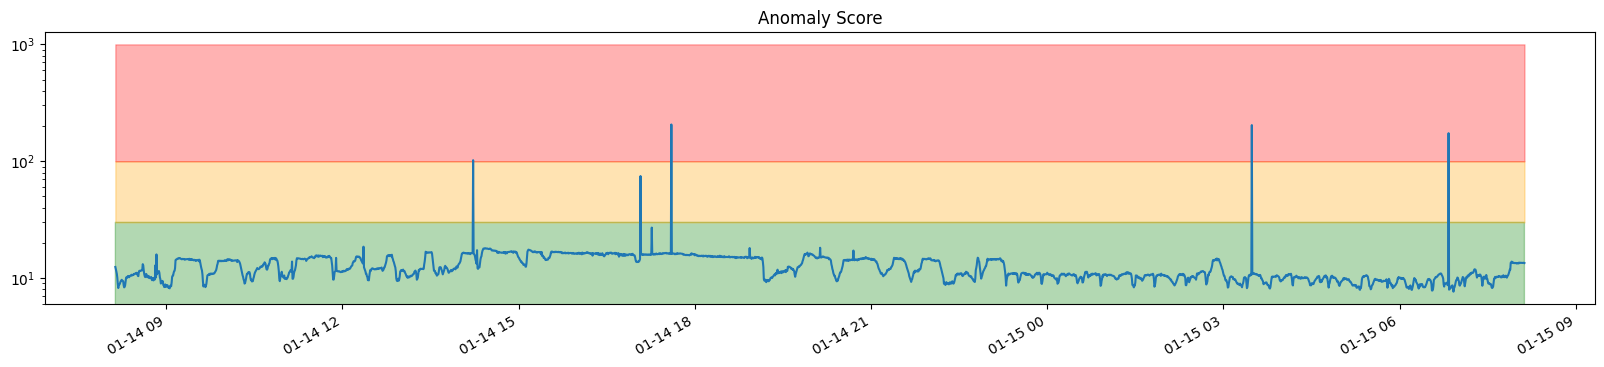

In [20]:
# normalize the data
X = scaler.transform(df)
# reshape inputs for LSTM [samples, timesteps, features]
X = X.reshape(X.shape[0], 1, X.shape[1])
print("Training data shape:", X.shape)

X_pred = model.predict(X)
X_pred = X_pred .reshape(X_pred .shape[0], X_pred .shape[2])
X_pred = pd.DataFrame(X_pred , columns=df.columns)
X_pred_original = scaler.inverse_transform(X_pred) #Se guarda la prediccion en otro DS
X_pred.index = df.index
scored = pd.DataFrame(index=df.index)
X_reshaped = X.reshape(X.shape[0], X.shape[2])
scored['Loss_mae'] = np.mean(np.abs(X_pred - X_reshaped), axis=1)
scored['Threshold'] = threshold


#concatenar scored_train y scored_test
scored.columns=['Resultados.Turbina.Factor de Anomalia Turbina', 'Resultados.Turbina.Umbral Anomalia Turbina']
scored['Resultados.Turbina.Factor de Anomalia Turbina'] = 100*scored['Resultados.Turbina.Factor de Anomalia Turbina'] / scored['Resultados.Turbina.Umbral Anomalia Turbina']
scored['Resultados.Turbina.Factor de Anomalia Turbina'] = scored['Resultados.Turbina.Factor de Anomalia Turbina'].clip(upper=110)
scored['Resultados.Turbina.Umbral Anomalia Turbina'] = 100


scored['Resultados.Turbina.Factor de Anomalia Turbina'] = 0.2*scored['Resultados.Turbina.Factor de Anomalia Turbina'] + anomaly_scores['total_score']
scored['Resultados.Turbina.Anomalia Turbina'] = scored['Resultados.Turbina.Factor de Anomalia Turbina'] > scored['Resultados.Turbina.Umbral Anomalia Turbina']
scored['Resultados.Turbina.Factor de Anomalia Turbina'] = scored['Resultados.Turbina.Factor de Anomalia Turbina'].clip(upper=1000)
scored['Resultados.Turbina.Anomalia Turbina'] = scored['Resultados.Turbina.Anomalia Turbina'].astype(int)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(20, 4))

# Graficar los datos

scored['Resultados.Turbina.Factor de Anomalia Turbina'].plot(ax=ax, title='Anomaly Score') #.iloc[25000:25500]

# Cambiar la escala del eje y a logarítmica
ax.set_yscale('log')

#Agregar 'mean_plus_2std' y 'mean_minus_2std' como una banda sombreada entre mean_plus_2std y mean_minus_2std
plt.fill_between(scored.index, 0, 30, color='green', alpha=0.3)
plt.fill_between(scored.index, 30, 100, color='orange', alpha=0.3)
plt.fill_between(scored.index, 100, 1000, color='red', alpha=0.3)

# Mostrar el g
plt.show()

In [21]:
scored.tail(3)

,Resultados.Turbina.Factor de Anomalia Turbina,Resultados.Turbina.Umbral Anomalia Turbina,Resultados.Turbina.Anomalia Turbina
2025-01-15 08:06:30.466605100-05:00,13.506607,100,0
2025-01-15 08:07:00.466605100-05:00,13.521790,100,0
2025-01-15 08:07:30.466605100-05:00,13.446662,100,0


In [22]:
scored[scored['Resultados.Turbina.Anomalia Turbina'] ==1]

,Resultados.Turbina.Factor de Anomalia Turbina,Resultados.Turbina.Umbral Anomalia Turbina,Resultados.Turbina.Anomalia Turbina
2025-01-14 14:13:30.466605100-05:00,102.051488,100,1
2025-01-14 17:36:00.466605100-05:00,206.258267,100,1
2025-01-15 03:29:00.466605100-05:00,203.791445,100,1
2025-01-15 06:50:00.466605100-05:00,173.795819,100,1


In [23]:
scored.index = pd.to_datetime(scored.index)
scored.reset_index(inplace=True)

# Cambiar el nombre de la columna 'index' a 'timestamp' si es necesario
if 'index' in scored.columns:
    scored.rename(columns={'index': 'timestamp'}, inplace=True)

scored['timestamp'] = pd.to_datetime(scored['timestamp']).dt.strftime('%m/%d/%Y %H:%M:%S')


In [24]:
scored[scored['Resultados.Turbina.Anomalia Turbina'] ==1]

,timestamp,Resultados.Turbina.Factor de Anomalia Turbina,Resultados.Turbina.Umbral Anomalia Turbina,Resultados.Turbina.Anomalia Turbina
731,01/14/2025 14:13:30,102.051488,100,1
1136,01/14/2025 17:36:00,206.258267,100,1
2322,01/15/2025 03:29:00,203.791445,100,1
2724,01/15/2025 06:50:00,173.795819,100,1


In [25]:
scored.to_csv('//PEAAAUCOI211/CSV Import/Resultados/deployment_turbina.csv',index=False)

In [26]:
# spy.push(scored,workbook='0EF325BC-6CF4-75A0-892B-6919F7C0F12A',worksheet='0EF35599-C02D-EED0-B552-0B20333CB776')

### 7. CALCULO DE IMPORTANCIAS

In [27]:
df_desfase = anomaly_scores.copy()
df_desfase.drop(columns=['total_score'], inplace=True)
#Agregar a las columnas de df_desfase el '_desfase' al final de cada nombre
df_desfase.columns = ['Resultados.Turbina.desfases.' + column + '_desfase' for column in df_desfase.columns]


In [28]:
df_desfase

,Resultados.Turbina.desfases.Condensador/FT_Caudal_desfase,Resultados.Turbina.desfases.Condensador/TT_Condensado_desfase,Resultados.Turbina.desfases.Condensador/Trip_SP_desfase,Resultados.Turbina.desfases.Condensador/PT_VacioCond_desfase,Resultados.Turbina.desfases.Condensador/LP_Extraccion_desfase,Resultados.Turbina.desfases.U. Lub/TT_Aceite_desfase,Resultados.Turbina.desfases.U. Lub/PT_Filtro_desfase,Resultados.Turbina.desfases.U. Lub/PT_Aceite_desfase,Resultados.Turbina.desfases.Param. Op./SPD_Gen_01_desfase,Resultados.Turbina.desfases.Param. Op./PT_Ingreso_desfase,...,Resultados.Turbina.desfases.Param. Estado/TT_RadialLL_desfase,Resultados.Turbina.desfases.Param. Estado/VT_ReductorLeftLA_desfase,Resultados.Turbina.desfases.Param. Estado/VT_ReductorRightLA_desfase,Resultados.Turbina.desfases.Param. Estado/VT_ReductorLeftLL_desfase,Resultados.Turbina.desfases.Param. Estado/VT_ReductorRightLL_desfase,Resultados.Turbina.desfases.Param. Estado/VT_TurbLLA_desfase,Resultados.Turbina.desfases.Param. Estado/VT_TurbLLB_desfase,Resultados.Turbina.desfases.Param. Estado/VT_TurbLAA_desfase,Resultados.Turbina.desfases.Param. Estado/VT_TurbLAB_desfase,Resultados.Turbina.desfases.Param. Estado/TT_MEAN_GEN_desfase
2025-01-14 08:08:00.466605100-05:00,16.064612,0.269774,12.628170,3.895066,30.774336,2.119448,7.558768,5.519573,4.306702,4.016261,...,3.220216,4.942184,27.602363,1.521613,5.907137,0.0,2.488603,8.232903,18.485161,1.326759
2025-01-14 08:08:30.466605100-05:00,15.430958,0.251582,11.645849,3.896296,30.514379,2.231678,7.551080,5.494690,4.317861,3.784461,...,3.220216,4.942184,27.529684,1.355021,5.565670,0.0,2.547247,8.151809,19.191690,1.326759
2025-01-14 08:09:00.466605100-05:00,16.792765,0.283070,10.351303,3.890147,30.168283,2.066635,7.830343,4.328504,4.263653,3.460073,...,3.220216,4.942184,27.575730,1.550591,5.521622,0.0,2.606358,8.531665,18.466702,1.326759
2025-01-14 08:09:30.466605100-05:00,15.581472,0.388204,11.293562,3.860145,30.006862,2.066635,7.559518,5.895656,4.264750,3.067947,...,3.220216,4.942184,27.860010,1.816746,5.467000,0.0,2.926562,8.261191,18.560895,1.326759
2025-01-14 08:10:00.466605100-05:00,16.109466,0.589897,11.346295,3.789932,23.984007,2.270847,8.033103,4.956726,4.262106,2.626791,...,3.220216,4.942184,27.582492,1.515382,5.358514,0.0,2.947559,8.647337,18.438597,1.326759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-15 08:05:30.466605100-05:00,16.365052,2.002020,19.539150,4.152633,31.570644,0.706030,7.657396,5.249364,4.156080,1.300536,...,0.881220,4.146263,27.401612,5.173164,7.915929,0.0,1.078586,7.641522,17.188199,0.103357
2025-01-15 08:06:00.466605100-05:00,15.988716,1.968260,19.849045,4.153904,31.571433,0.706030,7.703402,5.466049,4.169708,1.247336,...,0.881220,4.146263,27.531122,5.013726,7.813133,0.0,2.387956,7.341917,17.849168,0.103357
2025-01-15 08:06:30.466605100-05:00,16.860051,1.984004,19.209429,4.157593,31.571433,0.706030,7.836843,5.416848,4.169277,1.101250,...,0.881220,4.146263,27.582791,4.774341,8.074517,0.0,0.728822,7.526214,18.115673,0.103357
2025-01-15 08:07:00.466605100-05:00,16.839607,2.107151,20.392116,4.212844,31.570737,0.706030,7.308880,3.343529,4.189067,0.974087,...,0.881220,4.146263,27.485401,4.585867,7.828121,0.0,0.702424,7.240963,18.288036,0.103357


In [29]:
# Contar cuántas filas de cada columna de anomaly_scores son mayores a 100 y contar como porcentaje del número de filas
count_greater_than_100 = 100*df_desfase.apply(lambda x: (x > 100).sum())/df_desfase.shape[0]


# Mostrar los resultados
print(count_greater_than_100)

Resultados.Turbina.desfases.Condensador/FT_Caudal_desfase               0.000000
Resultados.Turbina.desfases.Condensador/TT_Condensado_desfase           0.000000
Resultados.Turbina.desfases.Condensador/Trip_SP_desfase                 0.000000
Resultados.Turbina.desfases.Condensador/PT_VacioCond_desfase            0.000000
Resultados.Turbina.desfases.Condensador/LP_Extraccion_desfase           0.000000
Resultados.Turbina.desfases.U. Lub/TT_Aceite_desfase                    0.000000
Resultados.Turbina.desfases.U. Lub/PT_Filtro_desfase                    0.000000
Resultados.Turbina.desfases.U. Lub/PT_Aceite_desfase                    0.000000
Resultados.Turbina.desfases.Param. Op./SPD_Gen_01_desfase               0.000000
Resultados.Turbina.desfases.Param. Op./PT_Ingreso_desfase               0.000000
Resultados.Turbina.desfases.Param. Op./PT_Turb_desfase                  0.000000
Resultados.Turbina.desfases.Param. Op./Pot_Act_desfase                  0.000000
Resultados.Turbina.desfases.

In [30]:
df_desfase.index = pd.to_datetime(df_desfase.index)
df_desfase.reset_index(inplace=True)

# Cambiar el nombre de la columna 'index' a 'timestamp' si es necesario
if 'index' in df_desfase.columns:
    df_desfase.rename(columns={'index': 'timestamp'}, inplace=True)

df_desfase['timestamp'] = pd.to_datetime(df_desfase['timestamp']).dt.strftime('%m/%d/%Y %H:%M:%S')

In [31]:
df_desfase.to_csv('//PEAAAUCOI211/CSV Import/Resultados/desfases_turbina.csv',index=False)

In [32]:
# spy.push(df_desfase,workbook='0EF325BC-6CF4-75A0-892B-6919F7C0F12A',worksheet='0EF35599-C02D-EED0-B552-0B20333CB776')

In [33]:
# spy.jobs.schedule('every 2 minutes')
# #spy.jobs.unschedule()